# ABMIL example

This notebook demonstrates a quick end-to-end CCDI-MCI workflow: (1) retrieve public clinical labels from CCDI cBioPortal, (2) join them to the released embedding manifest, (3) download a small balanced cohort from Hugging Face, and (4) train a attention-based multiple-instance learning (ABMIL) classifier.

The example predicts the cBioPortal sample-level **Cancer Type** attribute: **High-Grade Glioma** versus **Low-Grade Glioma**. It is intended as a usage example, but can be expanded as needed. 

## Setup

`huggingface_hub`, `requests`, `pandas`, `numpy`, `h5py`, `scikit-learn`, `matplotlib`, and `torch` are needed
+ authenticating hf with a login can improve the rate limits 

In [38]:
# %pip install -q "huggingface_hub>=1.31" requests pandas numpy h5py scikit-learn matplotlib torch

In [39]:
from copy import deepcopy
from pathlib import Path
import random

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import torch

from huggingface_hub import hf_hub_download
from sklearn.metrics import (
    ConfusionMatrixDisplay, balanced_accuracy_score, f1_score, roc_auc_score,
)
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, Dataset

DATA_DIR = Path("ccdi_mci_demo_data")
embedding_model = "conch_v15"  # "conch_v15" or "uni2h"

embedding_config = {
    "conch_v15": {
        "availability_column": "has_conch_v15",
        "feature_dim": 768,
        "display_name": "CONCH v1.5",
    },
    "uni2h": {
        "availability_column": "has_uni2h",
        "feature_dim": 1536,
        "display_name": "UNI2-h",
    },
}

embedding_config = embedding_config[embedding_model]
N_PER_CLASS = 200  # Set to None to use every matched patient.

LABEL_TO_ID = {"Low-Grade Glioma": 0, "High-Grade Glioma": 1}
CLASS_NAMES = list(LABEL_TO_ID)
print(CLASS_NAMES)

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device}")
print(f"Using {embedding_config['display_name']} ({embedding_config['feature_dim']}-D features)")

['Low-Grade Glioma', 'High-Grade Glioma']
Using cpu
Using CONCH v1.5 (768-D features)


## Retrieve and join the clinical and imaging metadata

`CANCER_TYPE` is a sample-level clinical attribute in this study. The returned `patientId` joins to `patient_id` in the embedding release manifest. Other clinical attributes area available on cbioportal including the methylation class

In [40]:
manifest_path = hf_hub_download(
    repo_id="CBIIT-CGBB/CCDI-MCI",
    repo_type="dataset",
    filename="metadata/slide_manifest.csv",
    local_dir=DATA_DIR,
)
manifest = pd.read_csv(manifest_path)

response = requests.get(
    "https://cbioportal-api.ccdi.cancer.gov/api/studies/phs002790/clinical-data",
    params={
        "clinicalDataType": "SAMPLE",
    },
    timeout=60,
)
response.raise_for_status()
clinical_records = response.json()

clinical = pd.DataFrame(
    {"patient_id": record["patientId"], "cancer_type": record["value"]}
    for record in clinical_records
    if record.get("clinicalAttributeId") == "CANCER_TYPE"
    and record.get("value") in CLASS_NAMES
).drop_duplicates()

clinical = clinical.drop_duplicates("patient_id")

eligible_slides = manifest.loc[
    manifest[embedding_config["availability_column"]].fillna(False),
    ["patient_id", "series_instance_uid"],
].merge(clinical, on="patient_id", how="inner")


patients = (
    eligible_slides[["patient_id", "cancer_type"]]
    .drop_duplicates()
    .sort_values("patient_id")
    .reset_index(drop=True)
)

print(f"Matched patients: {patients['patient_id'].nunique():,}")
display(patients["cancer_type"].value_counts().rename("patients").to_frame())

Matched patients: 1,142


,patients
cancer_type,
Low-Grade Glioma,741
High-Grade Glioma,401


In [41]:
if N_PER_CLASS is None:
    cohort = patients.copy()
else:
    # sample a smaller cohort of patietns for this demo 
    available = patients["cancer_type"].value_counts()
    too_small = available[available < N_PER_CLASS]
    if not too_small.empty:
        raise ValueError(f"Requested {N_PER_CLASS} patients per class, but found {too_small.to_dict()}")
    cohort = (
        patients.groupby("cancer_type", group_keys=False)
        .sample(n=N_PER_CLASS, random_state=seed)
        .sort_values("patient_id")
        .reset_index(drop=True)
    )

cohort["label"] = cohort["cancer_type"].map(LABEL_TO_ID).astype(int)
cohort_slides = eligible_slides.merge(cohort[["patient_id"]], on="patient_id")
print(f"Selected {len(cohort)} patients and {len(cohort_slides)} slides")
display(cohort["cancer_type"].value_counts().rename("patients").to_frame())

Selected 400 patients and 409 slides


,patients
cancer_type,
High-Grade Glioma,200
Low-Grade Glioma,200


## Download the selected patch embeddings

+ Downloads each manifest-listed slide for the selected patients using four concurrent workers. Re-running this cell reuses files already present in `DATA_DIR`.
+ This should take around a minute when downloading embeddings for 200 patients.

In [42]:
from __future__ import annotations

from collections.abc import Iterable
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

from huggingface_hub import hf_hub_download

"""
Concurrent download of files based on the full filename from the manifest
"""

def download_files(
    filenames: Iterable[str],
    local_dir: str | Path,
    *,
    repo_id: str = "CBIIT-CGBB/CCDI-MCI",
    repo_type: str = "dataset",
    max_workers: int = 4,
) -> list[Path]:
    """Download repository filenames concurrently"""
    if max_workers < 1:
        raise ValueError("max_workers must be at least 1")

    filenames = list(filenames)
    if not filenames:
        return []

    def download_file(filename: str) -> Path:
        return Path(
            hf_hub_download(
                repo_id=repo_id,
                repo_type=repo_type,
                filename=filename,
                local_dir=local_dir,
            )
        )

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        return list(executor.map(download_file, filenames))

In [43]:
selected_slides = (
    cohort_slides[["patient_id", "series_instance_uid"]]
    .drop_duplicates()
    .sort_values(["patient_id", "series_instance_uid"])
)

# get the exact filenames for the patients that we want to download
filenames = [
    f"embeddings/{embedding_model}/{row.patient_id}/{row.series_instance_uid}.h5"
    for row in selected_slides.itertuples(index=False)
]

downloaded_files = download_files(filenames, local_dir=DATA_DIR)

embedding_root = DATA_DIR / "embeddings" / embedding_model
patient_files = {
    patient_id: sorted((embedding_root / patient_id).glob("*.h5"))
    for patient_id in cohort["patient_id"]
}

cohort["feature_paths"] = cohort["patient_id"].map(patient_files)
print(f"Downloaded {len(downloaded_files)} HDF5 files")

Downloaded 409 HDF5 files


## Create patient-level splits and the patch bags

+ Splitting happens at the patient level 
+ For patients with multiple slides, all patch embeddings are concatenated into one bag (early fusion). Late fusion ABMIL would be an alternative to try.
+ Training bags are randomly capped at 2,048 instances without replacement. The validation and test bags use every available patch

In [44]:
train_df, remainder_df = train_test_split(
    cohort, test_size=0.30, stratify=cohort["label"], random_state=seed,
)
val_df, test_df = train_test_split(
    remainder_df, test_size=0.50, stratify=remainder_df["label"], random_state=seed,
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

display(pd.DataFrame({
    "train": train_df.cancer_type.value_counts(),
    "validation": val_df.cancer_type.value_counts(),
    "test": test_df.cancer_type.value_counts(),
}).fillna(0).astype(int))

,train,validation,test
cancer_type,,,
High-Grade Glioma,140,30,30
Low-Grade Glioma,140,30,30


In [45]:
class PatientBagDataset(Dataset):
    """One variable-length bag per patient, concatenating all of their slides."""

    def __init__(self, patient_df, feature_dim, training=False, max_instances=2_048, seed=42):
        self.patient_df = patient_df.reset_index(drop=True)
        self.feature_dim = feature_dim
        self.training = training
        self.max_instances = max_instances
        self.seed = seed
        self.epoch = 0

    def set_epoch(self, epoch):
        self.epoch = int(epoch)

    def __len__(self):
        return len(self.patient_df)

    def __getitem__(self, index):
        row = self.patient_df.iloc[index]
        slide_features = []
        for path in row["feature_paths"]:
            with h5py.File(path, "r") as handle:
                features = handle["features"][:].astype(np.float32) # feature bags can also be cached in memory during dataset construction if enough RAM is available
            if features.ndim != 2 or features.shape[1] != self.feature_dim:
                raise ValueError(
                    f"Expected (n_patches, {self.feature_dim}) features in {path}; "
                    f"got {features.shape}"
                )
            slide_features.append(features)
        if not slide_features:
            raise RuntimeError(f"No readable embeddings for {row['patient_id']}")

        features = np.concatenate(slide_features, axis=0)
        n_total = len(features)
        if self.training and self.max_instances is not None and n_total > self.max_instances:
            rng = np.random.default_rng(self.seed + self.epoch * len(self) + index)
            selected = rng.choice(n_total, self.max_instances, replace=False)
            features = features[selected]

        return (
            torch.from_numpy(features),
            torch.tensor(row["label"], dtype=torch.long),
            {"patient_id": row["patient_id"], "n_total": n_total, "n_used": len(features)},
        )

feature_dim = embedding_config["feature_dim"]
train_dataset = PatientBagDataset(train_df, feature_dim, training=True, seed=seed)
val_dataset = PatientBagDataset(val_df, feature_dim, seed=seed)
test_dataset = PatientBagDataset(test_df, feature_dim, seed=seed)

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0)

## Create and train a gated ABMIL model

The model projects each fixed patch embedding to 512 dimensions, learns a gated attention score for every patch, takes an attention-weighted sum over the patient bag, and classifies the resulting patient representation. The input width is selected automatically for CONCH v1.5 or UNI2-h.

In [46]:
class GatedABMIL(nn.Module):
    """Minimal gated-attention multiple-instance learning classifier.

    Implements the gated attention mechanism from Ilse, Tomczak,
    and Welling, *Attention-based Deep Multiple Instance Learning*, ICML
    2018: https://proceedings.mlr.press/v80/ilse18a.html

    The compact module layout is adapted from MIL-Lab, described by Shao
    et al., *Do Multiple Instance Learning Models Transfer?*, ICML 2025:
    https://proceedings.mlr.press/v267/shao25a.html
    https://github.com/mahmoodlab/MIL-Lab

    Args:
        input_dim: Width of each precomputed patch embedding.
        num_classes: Number of patient-level output classes.
        hidden_dim: Width of the projected patch features.
        attention_dim: Width of each gated-attention branch.
        dropout: Dropout probability in the attention branches.
    """

    def __init__(self, input_dim, num_classes, hidden_dim=512, attention_dim=384, dropout=0.25):
        super().__init__()
        self.patch_encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
        )
        self.attention_tanh = nn.Sequential(
            nn.Linear(hidden_dim, attention_dim),
            nn.Tanh(),
            nn.Dropout(dropout),
        )
        self.attention_sigmoid = nn.Sequential(
            nn.Linear(hidden_dim, attention_dim),
            nn.Sigmoid(),
            nn.Dropout(dropout),
        )
        self.attention_score = nn.Linear(attention_dim, 1)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, features):
        """Classify bags shaped [batch, patches, input_dim].

        Returns:
            logits: Patient-level scores shaped [batch, num_classes].
            attention: Normalized patch weights shaped [batch, 1, patches].
        """
        patch_features = self.patch_encoder(features)
        gated_attention = (
            self.attention_tanh(patch_features)
            * self.attention_sigmoid(patch_features)
        )
        attention_logits = self.attention_score(gated_attention).transpose(1, 2)
        attention = torch.softmax(attention_logits, dim=-1)
        patient_features = torch.bmm(attention, patch_features).squeeze(1)
        logits = self.classifier(patient_features)
        return logits, attention


model = GatedABMIL(
    input_dim=feature_dim,
    num_classes=len(CLASS_NAMES),
).to(device)

print(model)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters()):,}")

GatedABMIL(
  (patch_encoder): Sequential(
    (0): Linear(in_features=768, out_features=512, bias=True)
    (1): ReLU()
  )
  (attention_tanh): Sequential(
    (0): Linear(in_features=512, out_features=384, bias=True)
    (1): Tanh()
    (2): Dropout(p=0.25, inplace=False)
  )
  (attention_sigmoid): Sequential(
    (0): Linear(in_features=512, out_features=384, bias=True)
    (1): Sigmoid()
    (2): Dropout(p=0.25, inplace=False)
  )
  (attention_score): Linear(in_features=384, out_features=1, bias=True)
  (classifier): Linear(in_features=512, out_features=2, bias=True)
)
Trainable parameters: 789,123


In [47]:
@torch.no_grad()
def evaluate(model, loader, loss_fn):
    model.eval()
    losses, labels, predictions, probabilities, patient_ids = [], [], [], [], []
    for features, label, metadata in loader:
        features, label = features.to(device), label.to(device)
        logits, _ = model(features)
        losses.append(loss_fn(logits, label).item())
        probability = torch.softmax(logits, dim=1)
        labels.extend(label.cpu().numpy())
        predictions.extend(logits.argmax(dim=1).cpu().numpy())
        probabilities.extend(probability[:, 1].cpu().numpy())
        patient_ids.extend(metadata["patient_id"])
    return {
        "loss": float(np.mean(losses)),
        "labels": np.asarray(labels),
        "predictions": np.asarray(predictions),
        "probabilities": np.asarray(probabilities),
        "patient_ids": patient_ids,
    }

epoch 01 | train loss 0.4805 | val loss 0.4291
epoch 02 | train loss 0.3284 | val loss 0.3810
epoch 03 | train loss 0.3066 | val loss 0.3506
epoch 04 | train loss 0.2803 | val loss 0.3530
epoch 05 | train loss 0.2831 | val loss 0.3740
epoch 06 | train loss 0.2607 | val loss 0.3619
epoch 07 | train loss 0.2336 | val loss 0.4098
epoch 08 | train loss 0.2508 | val loss 0.4873
Early stopping


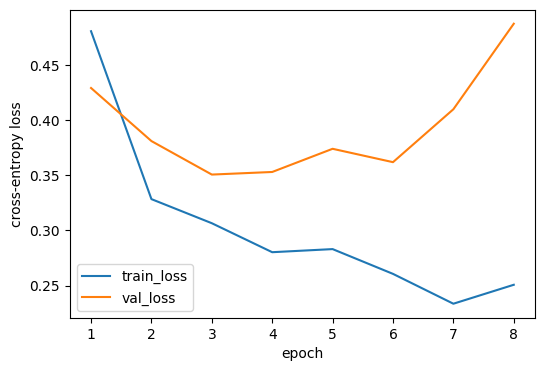

In [48]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=5e-4)
max_epochs, patience = 30, 5
best_state, best_val_loss, stale_epochs = None, float("inf"), 0
history = []

for epoch in range(max_epochs):
    model.train()
    train_dataset.set_epoch(epoch)
    train_losses = []
    for features, label, _ in train_loader:
        features, label = features.to(device), label.to(device)
        optimizer.zero_grad()
        logits, _ = model(features)
        loss = loss_fn(logits, label)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    validation = evaluate(model, val_loader, loss_fn)
    train_loss = float(np.mean(train_losses))
    history.append({"epoch": epoch + 1, "train_loss": train_loss, "val_loss": validation["loss"]})
    print(f"epoch {epoch + 1:02d} | train loss {train_loss:.4f} | val loss {validation['loss']:.4f}")

    if validation["loss"] < best_val_loss:
        best_val_loss = validation["loss"]
        best_state = deepcopy(model.state_dict())
        stale_epochs = 0
    else:
        stale_epochs += 1
        if stale_epochs >= patience:
            print("Early stopping")
            break

model.load_state_dict(best_state)
history_df = pd.DataFrame(history).set_index("epoch")
history_df.plot(y=["train_loss", "val_loss"], ylabel="cross-entropy loss", figsize=(6, 4));

## Eval on the test patients

,ABMIL test metric
balanced_accuracy,0.983333
macro_f1,0.983329
roc_auc,0.994444


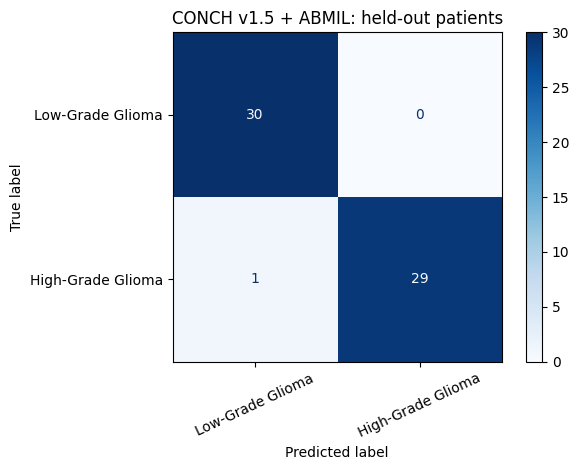

In [49]:
test_result = evaluate(model, test_loader, loss_fn)
test_metrics = {
    "balanced_accuracy": balanced_accuracy_score(test_result["labels"], test_result["predictions"]),
    "macro_f1": f1_score(test_result["labels"], test_result["predictions"], average="macro"),
    "roc_auc": roc_auc_score(test_result["labels"], test_result["probabilities"]),
}
display(pd.Series(test_metrics, name="ABMIL test metric").to_frame())

ConfusionMatrixDisplay.from_predictions(
    test_result["labels"],
    test_result["predictions"],
    display_labels=CLASS_NAMES,
    cmap="Blues",
    xticks_rotation=25,
)
plt.title(f"{embedding_config['display_name']} + ABMIL: held-out patients")
plt.tight_layout()
plt.show()

## Potential Additions

+ increase `N_PER_CLASS` or set it to `None`
+ repeat patient-level splits across several seeds
+ The released HDF5 files also contain patch coordinates, enabling visualization of ABMIL attention for downstream inspection. 
> Other potential addtions are discussed in our upcoming preprint